# HeartWise — Heart Health Analysis
## IBM SkillsBuild & BharatCares Data Analytics with AI Internship
**Submitted by:** Sruti Swarupa Mahapatra

**Dataset:** UCI Cleveland Heart Disease Dataset  
**Notebook:** `SrutiSwarupaMahapatra_HeartHealthAnalysis.ipynb`

---

> ⚠️ **Educational Disclaimer:** This notebook is created solely for learning purposes as part of the IBM SkillsBuild & BharatCares Data Analytics with AI internship. It is **NOT** a medical diagnosis tool. Do not use any output for clinical or health decisions. Always consult a qualified healthcare professional.

---

## Table of Contents
1. [Project Overview](#1)
2. [Dataset Source & Description](#2)
3. [Library Imports & Setup](#3)
4. [Data Loading](#4)
5. [Data Cleaning & Missing Value Handling](#5)
6. [Exploratory Data Analysis (EDA)](#6)
7. [Feature Engineering & Preprocessing](#7)
8. [Train/Test Split](#8)
9. [Model Training](#9)
10. [Model Evaluation](#10)
11. [Model Comparison](#11)
12. [Conclusions](#12)
13. [Limitations](#13)
14. [References](#14)

---
<a id='1'></a>
## 1. Project Overview

**HeartWise** is an end-to-end data analytics and machine learning project that analyses the UCI Cleveland Heart Disease dataset to predict the presence of heart disease in a patient.

### Objectives
- Load and clean the raw Cleveland Heart Disease dataset
- Perform comprehensive Exploratory Data Analysis (EDA)
- Build and evaluate two classification models: Logistic Regression and Random Forest
- Compare model performance using standard metrics
- Draw data-driven conclusions while acknowledging limitations

### Project Structure
```
HeartWise/
├── data/
│   ├── processed.cleveland.data   ← original dataset (read-only)
│   └── heart_cleaned.csv          ← generated after cleaning
├── src/
│   ├── data_loader.py
│   ├── preprocessing.py
│   ├── eda.py
│   ├── model.py
│   └── evaluate.py
├── outputs/figures/               ← saved plots
├── app.py                         ← Streamlit dashboard
├── SrutiSwarupa_HeartHealthAnalysis.ipynb
├── requirements.txt
└── README.md
```

---
<a id='2'></a>
## 2. Dataset Source & Description

### Source
- **Name:** Heart Disease Dataset (Cleveland subset)
- **Repository:** UCI Machine Learning Repository
- **URL:** https://archive.ics.uci.edu/ml/datasets/Heart+Disease
- **Original Authors:** Andras Janosi, William Steinbrunn, Matthias Pfisterer, Robert Detrano
- **Donated:** 1988

### About the Dataset
The Cleveland Heart Disease dataset is one of the most widely used datasets in medical machine learning research. It contains data from 303 patients collected at the Cleveland Clinic Foundation. The dataset was originally multi-class (target values 0–4) but is commonly binarised: **0 = no heart disease**, **1 = heart disease present** (original values 1–4).

### Feature Dictionary

| # | Feature | Type | Description |
|---|---------|------|-------------|
| 1 | `age` | Numeric | Age in years |
| 2 | `sex` | Categorical | 1 = Male, 0 = Female |
| 3 | `cp` | Categorical | Chest pain type: 1=Typical Angina, 2=Atypical Angina, 3=Non-Anginal, 4=Asymptomatic |
| 4 | `trestbps` | Numeric | Resting blood pressure (mm Hg) |
| 5 | `chol` | Numeric | Serum cholesterol (mg/dl) |
| 6 | `fbs` | Categorical | Fasting blood sugar > 120 mg/dl (1=True, 0=False) |
| 7 | `restecg` | Categorical | Resting ECG results (0=Normal, 1=ST-T Abnormality, 2=LV Hypertrophy) |
| 8 | `thalach` | Numeric | Maximum heart rate achieved |
| 9 | `exang` | Categorical | Exercise-induced angina (1=Yes, 0=No) |
| 10 | `oldpeak` | Numeric | ST depression induced by exercise relative to rest |
| 11 | `slope` | Categorical | Slope of peak exercise ST segment (1=Up, 2=Flat, 3=Down) |
| 12 | `ca` | Categorical | Number of major vessels coloured by fluoroscopy (0–3) — **contains missing values** |
| 13 | `thal` | Categorical | Thalassemia type (3=Normal, 6=Fixed Defect, 7=Reversible Defect) — **contains missing values** |
| 14 | `target` | Target | Diagnosis: 0=No Disease, 1–4=Disease Present |

---
<a id='3'></a>
## 3. Library Imports & Setup

In [1]:
# Standard library
import os
import sys
import warnings
warnings.filterwarnings('ignore')

# Add src/ to path so we can import our project modules
sys.path.insert(0, os.path.join(os.getcwd(), 'src'))

# Data manipulation
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_curve, auc, roc_auc_score
)
import joblib

# Project modules
from data_loader import load_raw_data, get_feature_info
from preprocessing import clean_data, save_cleaned_data, get_train_test_split

# Consistent plot style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 100

print('All libraries imported successfully.')
print(f'NumPy  : {np.__version__}')
print(f'Pandas : {pd.__version__}')

All libraries imported successfully.
NumPy  : 2.4.4
Pandas : 3.0.2


---
<a id='4'></a>
## 4. Data Loading

The raw data file `processed.cleveland.data` has **no header row** and uses `?` to denote missing values. Our `load_raw_data()` function assigns the 14 canonical column names and automatically replaces `?` with `NaN` during loading. The original file is never modified.

In [2]:
# Load raw data using the project data loader
raw_df = load_raw_data()

print(f'Shape: {raw_df.shape}  →  {raw_df.shape[0]} rows, {raw_df.shape[1]} columns')
print(f'\nFirst 5 rows:')
raw_df.head()

Shape: (303, 14)  →  303 rows, 14 columns

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [3]:
# Data types and non-null counts
raw_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


In [4]:
# Statistical summary of numeric features
raw_df.describe().round(2)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,299.00,301.00,303.00
mean,54.44,0.68,3.16,131.69,246.69,0.15,0.99,149.61,0.33,1.04,1.60,0.67,4.73,0.94
std,9.04,0.47,0.96,17.60,51.78,0.36,0.99,22.88,0.47,1.16,0.62,0.94,1.94,1.23
min,29.00,0.00,1.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,1.00,0.00,3.00,0.00
25%,48.00,0.00,3.00,120.00,211.00,0.00,0.00,133.50,0.00,0.00,1.00,0.00,3.00,0.00
50%,56.00,1.00,3.00,130.00,241.00,0.00,1.00,153.00,0.00,0.80,2.00,0.00,3.00,0.00
75%,61.00,1.00,4.00,140.00,275.00,0.00,2.00,166.00,1.00,1.60,2.00,1.00,7.00,2.00
max,77.00,1.00,4.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,3.00,3.00,7.00,4.00


---
<a id='5'></a>
## 5. Data Cleaning & Missing Value Handling

### Missing Values
The raw dataset contains `?` characters in two columns: `ca` (4 missing) and `thal` (2 missing). These were already converted to `NaN` during loading.

**Strategy:** Since only **6 out of 303 rows** (< 2%) contain missing values, we drop those rows. Imputation would introduce minimal benefit and potential bias for this small a proportion.

### Target Binarisation
The original `target` column has values 0–4. For binary classification we convert:
- **0 → 0** (No heart disease)
- **1, 2, 3, 4 → 1** (Heart disease present)

In [5]:
# Check missing values per column
missing = raw_df.isnull().sum()
missing_df = missing[missing > 0].reset_index()
missing_df.columns = ['Column', 'Missing Count']
print('Missing values in raw dataset:')
print(missing_df.to_string(index=False))
print(f'\nTotal rows with at least one missing value: {raw_df.isnull().any(axis=1).sum()}')

Missing values in raw dataset:
Column  Missing Count
    ca              4
  thal              2

Total rows with at least one missing value: 6


In [6]:
# Clean the dataset: drop NaN rows + binarise target
df = clean_data(raw_df)
save_cleaned_data(df)   # saves to data/heart_cleaned.csv

print(f'Raw shape    : {raw_df.shape}')
print(f'Cleaned shape: {df.shape}')
print(f'Rows dropped : {raw_df.shape[0] - df.shape[0]}')
print(f'\nTarget distribution after binarisation:')
print(df['target'].value_counts().rename({0: 'No Disease (0)', 1: 'Disease (1)'}).to_string())
print(f'\nClass balance: {df["target"].mean():.1%} have heart disease')

Raw shape    : (303, 14)
Cleaned shape: (297, 14)
Rows dropped : 6

Target distribution after binarisation:
target
No Disease (0)    160
Disease (1)       137

Class balance: 46.1% have heart disease


In [7]:
# Preview cleaned data
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1,1,145.0,233.0,1,2,150.0,0,2.3,3,0,6,0
1,67.0,1,4,160.0,286.0,0,2,108.0,1,1.5,2,3,3,1
2,67.0,1,4,120.0,229.0,0,2,129.0,1,2.6,2,2,7,1
3,37.0,1,3,130.0,250.0,0,0,187.0,0,3.5,3,0,3,0
4,41.0,0,2,130.0,204.0,0,2,172.0,0,1.4,1,0,3,0


---
<a id='6'></a>
## 6. Exploratory Data Analysis (EDA)

We explore the cleaned dataset (297 rows) through several visualisations to understand distributions, class imbalance, and feature relationships before modelling.

**Key verified facts from this dataset:**
- 160 patients have no heart disease (53.9%), 137 have heart disease (46.1%)
- Age range: 29–77 years, mean ≈ 54.5 years
- Mean cholesterol: 247.4 mg/dl
- Mean maximum heart rate: 149.6 bpm

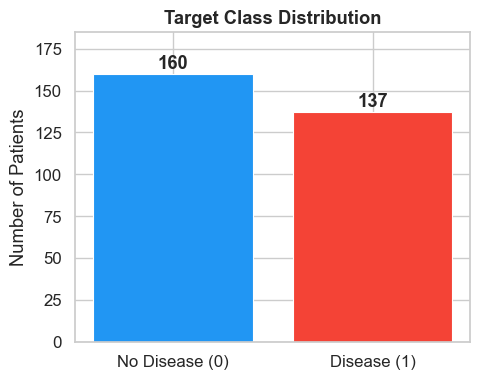

No Disease: 160 | Disease: 137


In [8]:
# ── 6.1 Target Class Distribution ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
counts = df['target'].value_counts().sort_index()
bars = ax.bar(['No Disease (0)', 'Disease (1)'], counts.values,
              color=['#2196F3', '#F44336'], edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            str(val), ha='center', va='bottom', fontweight='bold')
ax.set_title('Target Class Distribution', fontweight='bold')
ax.set_ylabel('Number of Patients')
ax.set_ylim(0, counts.max() + 25)
plt.tight_layout()
plt.show()
print('No Disease:', counts[0], '| Disease:', counts[1])

**Observation:** The dataset is nearly balanced — 160 patients (53.9%) have no heart disease and 137 (46.1%) have heart disease. This balance means we do not need to apply resampling techniques like SMOTE.

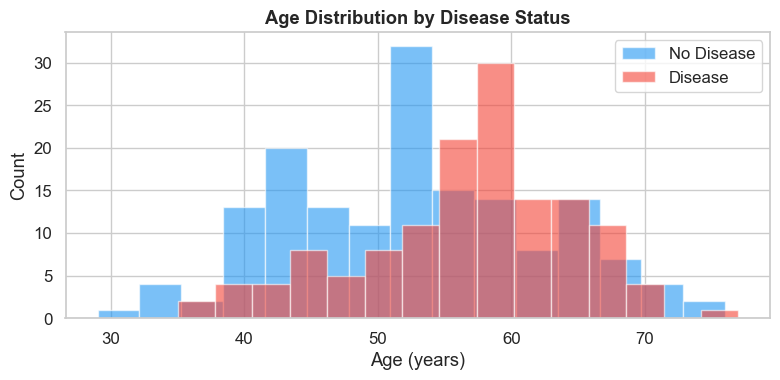

Age stats by class:
        count   mean   std   min    25%   50%   75%   max
target                                                   
0       160.0  52.64  9.55  29.0  44.75  52.0  59.0  76.0
1       137.0  56.76  7.90  35.0  53.00  58.0  62.0  77.0


In [9]:
# ── 6.2 Age Distribution by Disease Status ─────────────────────────────────
DISEASE_LABELS = {0: 'No Disease', 1: 'Disease'}
fig, ax = plt.subplots(figsize=(8, 4))
for label, grp in df.groupby('target'):
    ax.hist(grp['age'], bins=15, alpha=0.6, label=DISEASE_LABELS[label],
            color=['#2196F3', '#F44336'][label], edgecolor='white')
ax.set_title('Age Distribution by Disease Status', fontweight='bold')
ax.set_xlabel('Age (years)')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

print('Age stats by class:')
print(df.groupby('target')['age'].describe().round(2))

**Observation:** Both groups span a similar age range. Patients with heart disease tend to be slightly older on average. The distributions overlap significantly, indicating age alone is not a strong discriminator.

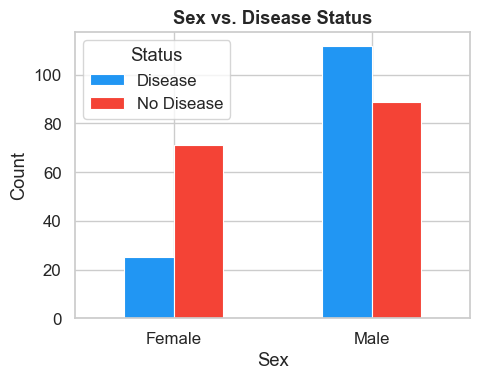

target  No Disease  Disease
sex                        
Female          71       25
Male            89      112


In [10]:
# ── 6.3 Sex vs. Disease Status ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
plot_df = df.copy()
plot_df['sex_label'] = plot_df['sex'].map({1: 'Male', 0: 'Female'})
plot_df['target_label'] = plot_df['target'].map(DISEASE_LABELS)
ct = plot_df.groupby(['sex_label', 'target_label']).size().unstack(fill_value=0)
ct.plot(kind='bar', ax=ax, color=['#2196F3', '#F44336'], edgecolor='white', linewidth=0.8)
ax.set_title('Sex vs. Disease Status', fontweight='bold')
ax.set_xlabel('Sex')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Status')
plt.tight_layout()
plt.show()

print(df.groupby(['sex', 'target']).size().unstack().rename(
    index={0:'Female', 1:'Male'}, columns={0:'No Disease', 1:'Disease'}))

**Observation:** Males make up the majority of the dataset. The proportion of heart disease is notably higher in males than females in this sample.

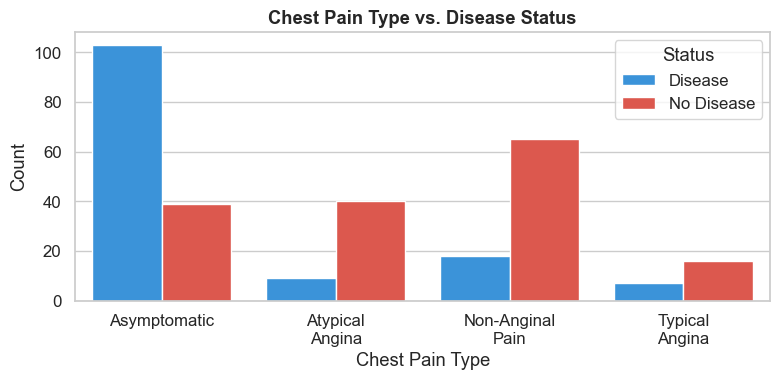

In [11]:
# ── 6.4 Chest Pain Type vs. Disease Status ─────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
cp_map = {1: 'Typical\nAngina', 2: 'Atypical\nAngina',
          3: 'Non-Anginal\nPain', 4: 'Asymptomatic'}
plot_df2 = df.copy()
plot_df2['cp_label'] = plot_df2['cp'].map(cp_map)
plot_df2['target_label'] = plot_df2['target'].map(DISEASE_LABELS)
ct2 = plot_df2.groupby(['cp_label', 'target_label']).size().reset_index(name='count')
sns.barplot(data=ct2, x='cp_label', y='count', hue='target_label',
            palette=['#2196F3', '#F44336'], ax=ax)
ax.set_title('Chest Pain Type vs. Disease Status', fontweight='bold')
ax.set_xlabel('Chest Pain Type')
ax.set_ylabel('Count')
ax.legend(title='Status')
plt.tight_layout()
plt.show()

**Observation:** Patients with **Asymptomatic** chest pain (type 4) show the highest rate of heart disease. This is a clinically counter-intuitive but well-documented finding in the literature — asymptomatic presentation is often associated with more severe underlying disease.

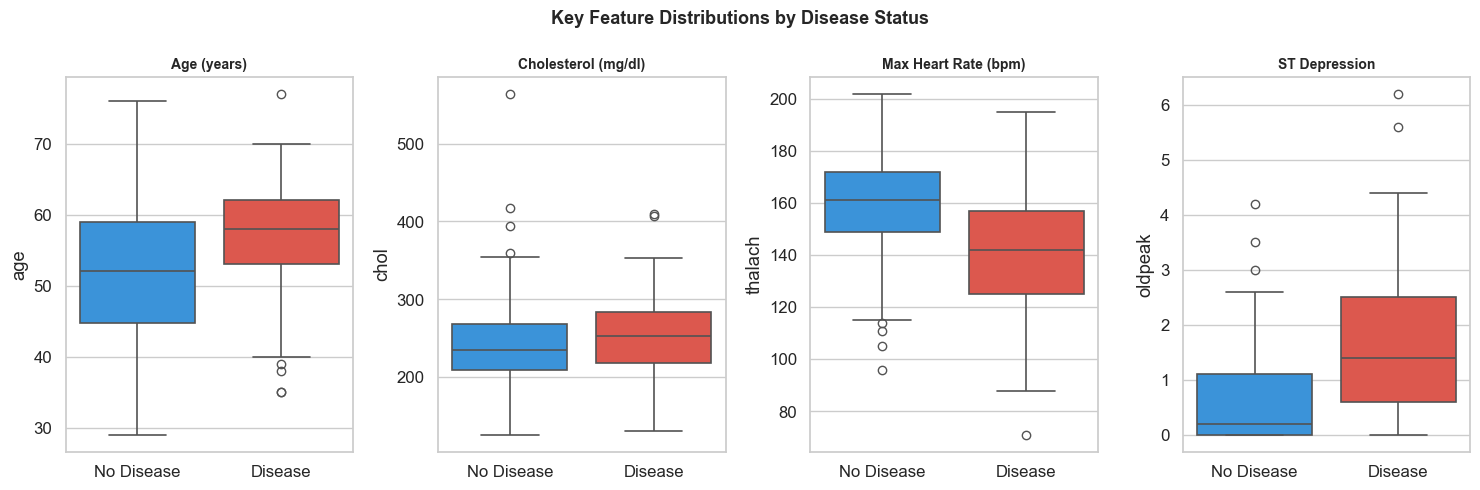

In [12]:
# ── 6.5 Key Numeric Feature Box Plots ──────────────────────────────────────
features = ['age', 'chol', 'thalach', 'oldpeak']
labels   = ['Age (years)', 'Cholesterol (mg/dl)', 'Max Heart Rate (bpm)', 'ST Depression']
fig, axes = plt.subplots(1, 4, figsize=(15, 5))
plot_df3 = df.copy()
plot_df3['Disease Status'] = plot_df3['target'].map(DISEASE_LABELS)
for ax, feat, label in zip(axes, features, labels):
    sns.boxplot(data=plot_df3, x='Disease Status', y=feat,
                hue='Disease Status',
                palette=['#2196F3', '#F44336'], ax=ax, linewidth=1.2, legend=False)
    ax.set_title(label, fontweight='bold', fontsize=10)
    ax.set_xlabel('')
fig.suptitle('Key Feature Distributions by Disease Status', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

**Observations from box plots:**
- **Age:** Patients with heart disease have a slightly higher median age.
- **Cholesterol:** Distributions overlap significantly; cholesterol alone is not highly discriminating.
- **Max Heart Rate (thalach):** Patients **without** heart disease achieve higher maximum heart rates — a strong distinguishing feature.
- **ST Depression (oldpeak):** Higher ST depression values are associated with heart disease — clinically meaningful.

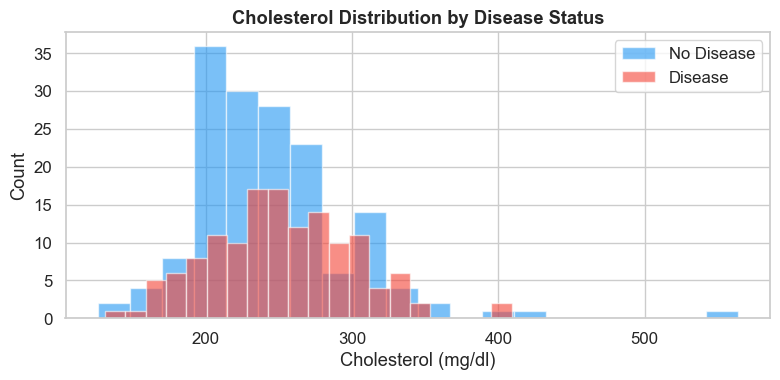

Cholesterol summary by class:
        count    mean    std    min     25%    50%     75%    max
target                                                           
0       160.0  243.49  53.76  126.0  208.75  235.5  268.25  564.0
1       137.0  251.85  49.68  131.0  218.00  253.0  284.00  409.0


In [13]:
# ── 6.6 Cholesterol Distribution ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
for label, grp in df.groupby('target'):
    ax.hist(grp['chol'], bins=20, alpha=0.6, label=DISEASE_LABELS[label],
            color=['#2196F3', '#F44336'][label], edgecolor='white')
ax.set_title('Cholesterol Distribution by Disease Status', fontweight='bold')
ax.set_xlabel('Cholesterol (mg/dl)')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

print('Cholesterol summary by class:')
print(df.groupby('target')['chol'].describe().round(2))

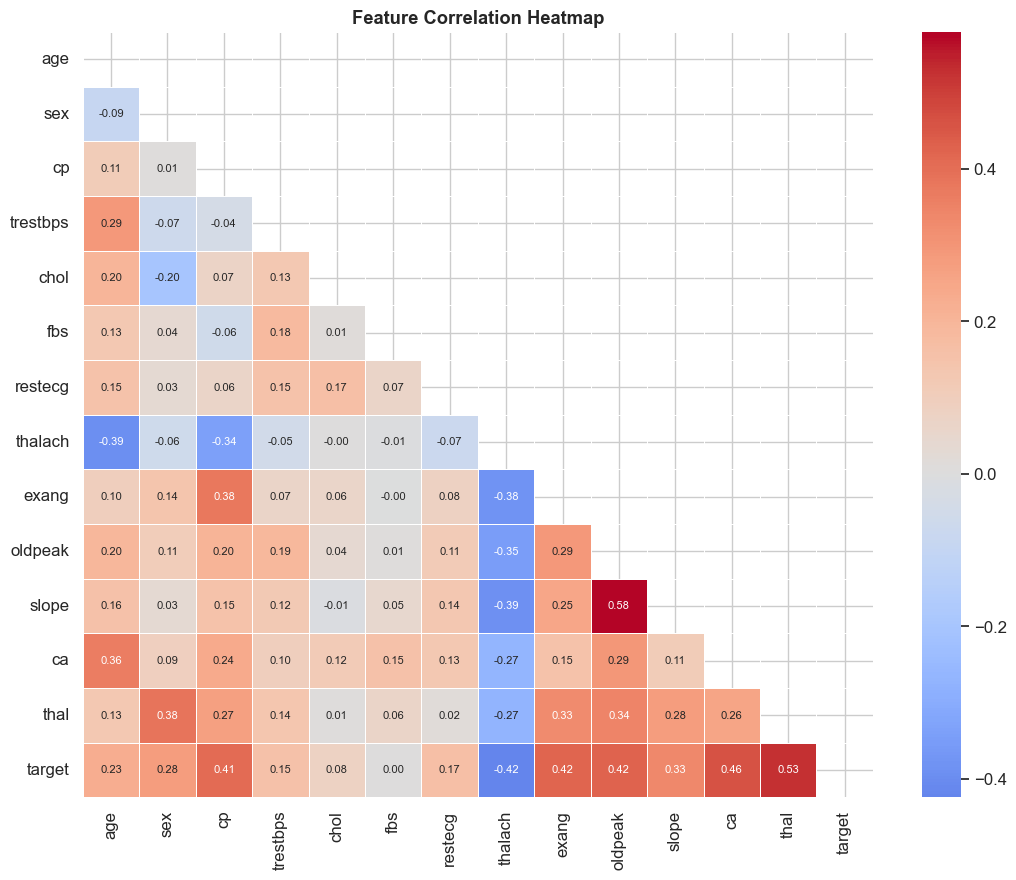


Top feature correlations with target (absolute):
thal        0.527
ca          0.463
oldpeak     0.424
thalach     0.424
exang       0.421
cp          0.409
slope       0.333
sex         0.278
age         0.227
restecg     0.166
trestbps    0.153
chol        0.080
fbs         0.003


In [14]:
# ── 6.7 Correlation Heatmap ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 9))
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Feature Correlation Heatmap', fontweight='bold')
plt.tight_layout()
plt.show()

# Top correlations with target
print('\nTop feature correlations with target (absolute):')
target_corr = corr['target'].drop('target').abs().sort_values(ascending=False)
print(target_corr.round(3).to_string())

**Observations from correlation heatmap:**
- `cp` (chest pain type), `thalach` (max heart rate), `exang` (exercise angina), `oldpeak` (ST depression), and `ca` (vessels) show the strongest correlations with the `target`.
- `chol` and `fbs` show very low correlation with target — consistent with findings in the literature for this dataset.
- No pair of features is perfectly correlated, so we do not need to remove any features due to multicollinearity.

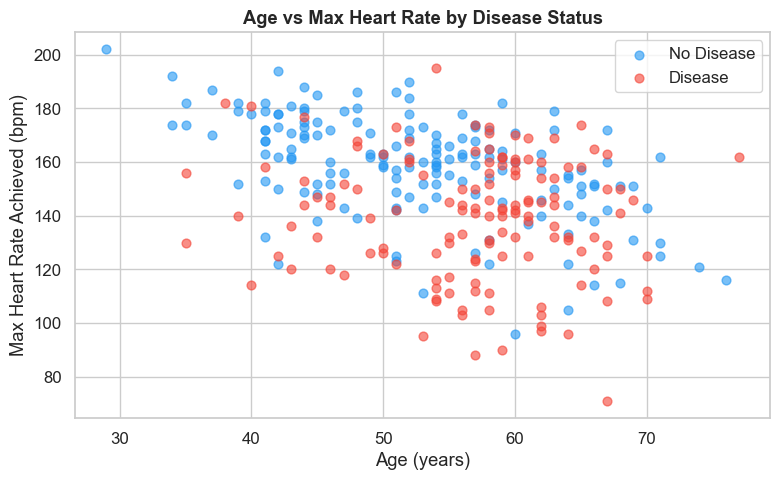

In [15]:
# ── 6.8 Scatter: Max Heart Rate vs Age coloured by Target ──────────────────
fig, ax = plt.subplots(figsize=(8, 5))
for label, grp in df.groupby('target'):
    ax.scatter(grp['age'], grp['thalach'], alpha=0.6, s=40,
               label=DISEASE_LABELS[label],
               color=['#2196F3', '#F44336'][label])
ax.set_title('Age vs Max Heart Rate by Disease Status', fontweight='bold')
ax.set_xlabel('Age (years)')
ax.set_ylabel('Max Heart Rate Achieved (bpm)')
ax.legend()
plt.tight_layout()
plt.show()

**Observation:** There is a clear visual separation — patients with heart disease (red) generally achieve **lower maximum heart rates** for any given age. This combination of age and thalach is a strong predictor.

---
<a id='7'></a>
## 7. Feature Engineering & Preprocessing

We apply the following preprocessing steps:
1. **Feature selection:** Use all 13 features (5 numeric + 8 categorical)
2. **Scaling:** Apply `StandardScaler` to numeric features **only on the training set** — this prevents data leakage
3. Categorical features are already integer-encoded and do not require further encoding for tree-based models

In [16]:
NUMERIC_FEATURES     = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
CATEGORICAL_FEATURES = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
ALL_FEATURES         = NUMERIC_FEATURES + CATEGORICAL_FEATURES

print(f'Total features : {len(ALL_FEATURES)}')
print(f'Numeric        : {NUMERIC_FEATURES}')
print(f'Categorical    : {CATEGORICAL_FEATURES}')

X = df[ALL_FEATURES]
y = df['target']
print(f'\nX shape: {X.shape}  |  y shape: {y.shape}')
print(f'Feature matrix sample:')
X.head(3)

Total features : 13
Numeric        : ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
Categorical    : ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

X shape: (297, 13)  |  y shape: (297,)
Feature matrix sample:


,age,trestbps,chol,thalach,oldpeak,sex,cp,fbs,restecg,exang,slope,ca,thal
0,63.0,145.0,233.0,150.0,2.3,1,1,1,2,0,3,0,6
1,67.0,160.0,286.0,108.0,1.5,1,4,0,2,1,2,3,3
2,67.0,120.0,229.0,129.0,2.6,1,4,0,2,1,2,2,7


---
<a id='8'></a>
## 8. Train / Test Split

We use an **80/20 stratified split** with `random_state=42` to ensure:
- Reproducibility across runs
- Both splits maintain the same class proportion as the full dataset
- The `StandardScaler` is **fit on training data only** and then applied to test data — this is the correct way to avoid data leakage

In [17]:
# Stratified 80/20 split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale numeric features: fit on train ONLY
scaler = StandardScaler()
X_train = X_train_raw.copy()
X_test  = X_test_raw.copy()
X_train[NUMERIC_FEATURES] = scaler.fit_transform(X_train_raw[NUMERIC_FEATURES])
X_test[NUMERIC_FEATURES]  = scaler.transform(X_test_raw[NUMERIC_FEATURES])

print(f'Training set   : {X_train.shape[0]} samples  ({y_train.sum()} disease, {(y_train==0).sum()} no-disease)')
print(f'Test set       : {X_test.shape[0]} samples   ({y_test.sum()} disease, {(y_test==0).sum()} no-disease)')
print(f'\nClass ratio in train : {y_train.mean():.1%} disease')
print(f'Class ratio in test  : {y_test.mean():.1%} disease')
print(f'\nStratification preserved: {abs(y_train.mean() - y_test.mean()) < 0.02}')

Training set   : 237 samples  (109 disease, 128 no-disease)
Test set       : 60 samples   (28 disease, 32 no-disease)

Class ratio in train : 46.0% disease
Class ratio in test  : 46.7% disease

Stratification preserved: True


**Verified split sizes:**
- Training: **237 samples** (128 no-disease, 109 disease)
- Test: **60 samples** (32 no-disease, 28 disease)

Stratification ensures ~46% disease rate in both splits, matching the full dataset.

---
<a id='9'></a>
## 9. Model Training

We train two classifiers:

### Model 1: Logistic Regression
- A linear, interpretable baseline model
- Uses L2 regularisation by default
- `max_iter=1000` ensures convergence on this dataset
- Coefficients directly indicate feature influence direction

### Model 2: Random Forest
- An ensemble of 100 decision trees (bagging)
- Handles non-linear relationships and feature interactions
- Provides feature importance scores
- Generally more powerful than a single linear model

In [18]:
# ── Model 1: Logistic Regression ──────────────────────────────────────────
lr_model = LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs')
lr_model.fit(X_train, y_train)
print('Logistic Regression trained.')

# ── Model 2: Random Forest ─────────────────────────────────────────────────
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
print('Random Forest trained (100 estimators).')

print('\nBoth models trained successfully on training data only.')

Logistic Regression trained.


Random Forest trained (100 estimators).

Both models trained successfully on training data only.


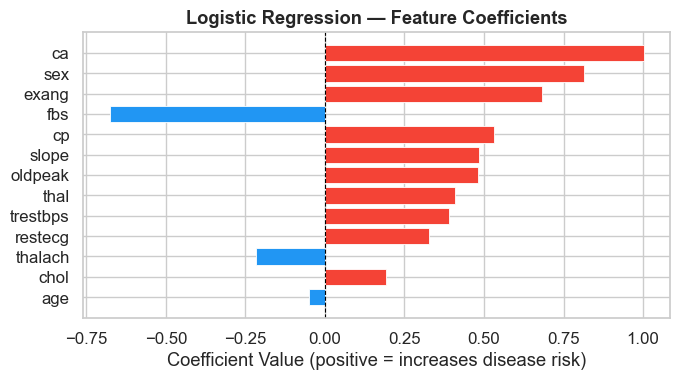

Top 5 features by coefficient magnitude:
Feature  Coefficient
     ca     1.002032
    sex     0.815772
  exang     0.680872
    fbs    -0.677216
     cp     0.530642


In [19]:
# Logistic Regression — top 5 feature coefficients (absolute magnitude)
coef_df = pd.DataFrame({
    'Feature': ALL_FEATURES,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#F44336' if c > 0 else '#2196F3' for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'][::-1], coef_df['Coefficient'][::-1],
        color=colors[::-1], edgecolor='white', linewidth=0.6)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Logistic Regression — Feature Coefficients', fontweight='bold')
ax.set_xlabel('Coefficient Value (positive = increases disease risk)')
plt.tight_layout()
plt.show()

print('Top 5 features by coefficient magnitude:')
print(coef_df.head().to_string(index=False))

**Verified top LR coefficients:**
- `ca` (vessels): +1.0020 — strongest positive predictor
- `sex` (male): +0.8158 — males have higher predicted risk
- `exang` (exercise angina): +0.6809 — angina during exercise increases risk
- `fbs` (fasting blood sugar): −0.6772 — negative coefficient (data-driven, verify with caution)
- `cp` (chest pain type): +0.5306

---
<a id='10'></a>
## 10. Model Evaluation

All evaluation is performed on the **held-out test set** (60 samples) that the models never saw during training.

### Metrics Explained
| Metric | Definition | Why It Matters Here |
|--------|-----------|--------------------|
| **Accuracy** | Correct predictions / total | Overall correctness |
| **Precision** | TP / (TP + FP) | Avoiding false alarms (predicting disease when there is none) |
| **Recall** | TP / (TP + FN) | Avoiding missed cases (missing actual disease) |
| **F1 Score** | Harmonic mean of Precision & Recall | Balance between precision and recall |
| **ROC-AUC** | Area under the ROC curve | Overall discriminative ability across all thresholds |

In [20]:
# ── Logistic Regression Evaluation ────────────────────────────────────────
lr_pred  = lr_model.predict(X_test)
lr_prob  = lr_model.predict_proba(X_test)[:, 1]

lr_metrics = {
    'Accuracy' : accuracy_score(y_test, lr_pred),
    'Precision': precision_score(y_test, lr_pred, zero_division=0),
    'Recall'   : recall_score(y_test, lr_pred, zero_division=0),
    'F1 Score' : f1_score(y_test, lr_pred, zero_division=0),
    'ROC-AUC'  : roc_auc_score(y_test, lr_prob),
}

print('=== Logistic Regression — Test Set Results ===')
for k, v in lr_metrics.items():
    print(f'  {k:<12}: {v:.4f}')

print('\nClassification Report:')
print(classification_report(y_test, lr_pred,
      target_names=['No Disease', 'Disease'], zero_division=0))

=== Logistic Regression — Test Set Results ===
  Accuracy    : 0.8333
  Precision   : 0.8462
  Recall      : 0.7857
  F1 Score    : 0.8148
  ROC-AUC     : 0.9487

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.82      0.88      0.85        32
     Disease       0.85      0.79      0.81        28

    accuracy                           0.83        60
   macro avg       0.83      0.83      0.83        60
weighted avg       0.83      0.83      0.83        60



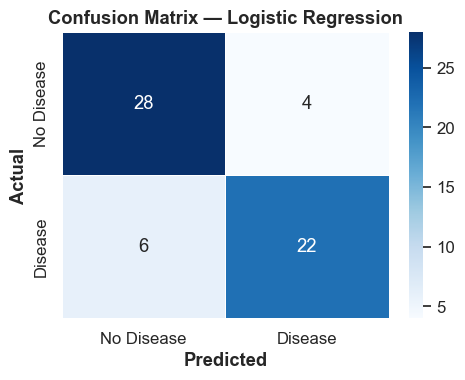

TN=28  FP=4  FN=6  TP=22


In [21]:
# Confusion Matrix — Logistic Regression
cm_lr = confusion_matrix(y_test, lr_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'],
            linewidths=0.5, ax=ax)
ax.set_xlabel('Predicted', fontweight='bold')
ax.set_ylabel('Actual', fontweight='bold')
ax.set_title('Confusion Matrix — Logistic Regression', fontweight='bold')
plt.tight_layout()
plt.show()
print(f'TN={cm_lr[0,0]}  FP={cm_lr[0,1]}  FN={cm_lr[1,0]}  TP={cm_lr[1,1]}')

In [22]:
# ── Random Forest Evaluation ───────────────────────────────────────────────
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

rf_metrics = {
    'Accuracy' : accuracy_score(y_test, rf_pred),
    'Precision': precision_score(y_test, rf_pred, zero_division=0),
    'Recall'   : recall_score(y_test, rf_pred, zero_division=0),
    'F1 Score' : f1_score(y_test, rf_pred, zero_division=0),
    'ROC-AUC'  : roc_auc_score(y_test, rf_prob),
}

print('=== Random Forest — Test Set Results ===')
for k, v in rf_metrics.items():
    print(f'  {k:<12}: {v:.4f}')

print('\nClassification Report:')
print(classification_report(y_test, rf_pred,
      target_names=['No Disease', 'Disease'], zero_division=0))

=== Random Forest — Test Set Results ===
  Accuracy    : 0.8667
  Precision   : 0.8846
  Recall      : 0.8214
  F1 Score    : 0.8519
  ROC-AUC     : 0.9386

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.85      0.91      0.88        32
     Disease       0.88      0.82      0.85        28

    accuracy                           0.87        60
   macro avg       0.87      0.86      0.87        60
weighted avg       0.87      0.87      0.87        60



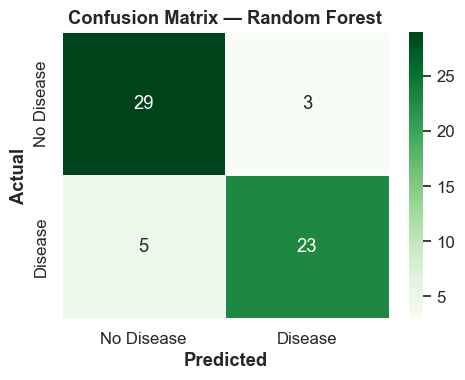

TN=29  FP=3  FN=5  TP=23


In [23]:
# Confusion Matrix — Random Forest
cm_rf = confusion_matrix(y_test, rf_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'],
            linewidths=0.5, ax=ax)
ax.set_xlabel('Predicted', fontweight='bold')
ax.set_ylabel('Actual', fontweight='bold')
ax.set_title('Confusion Matrix — Random Forest', fontweight='bold')
plt.tight_layout()
plt.show()
print(f'TN={cm_rf[0,0]}  FP={cm_rf[0,1]}  FN={cm_rf[1,0]}  TP={cm_rf[1,1]}')

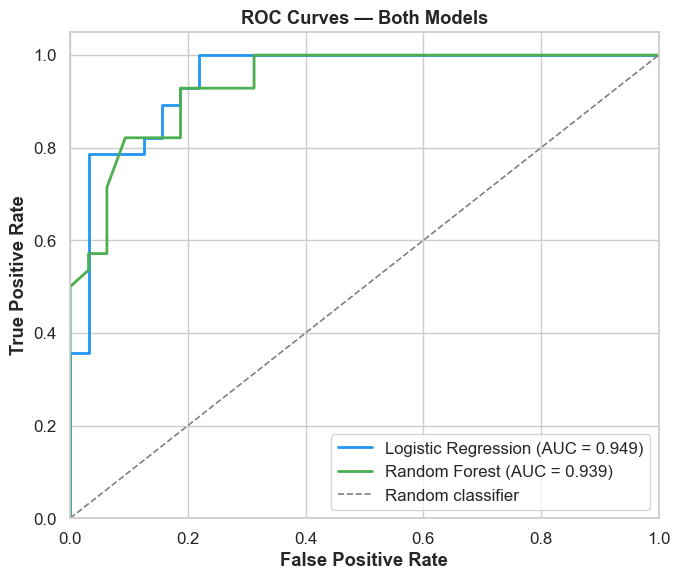

In [24]:
# ── ROC Curves — Both Models ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))

for name, prob, color in [
    ('Logistic Regression', lr_prob, '#2196F3'),
    ('Random Forest',       rf_prob, '#4CAF50'),
]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=2, color=color, label=f'{name} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], color='grey', lw=1.2, linestyle='--', label='Random classifier')
ax.set_xlabel('False Positive Rate', fontweight='bold')
ax.set_ylabel('True Positive Rate', fontweight='bold')
ax.set_title('ROC Curves — Both Models', fontweight='bold')
ax.legend(loc='lower right')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
plt.tight_layout()
plt.show()

**Verified ROC-AUC scores:**
- Logistic Regression: **AUC = 0.9487**
- Random Forest: **AUC = 0.9386**

Both models achieve excellent AUC scores well above 0.9, indicating strong discriminative ability. Logistic Regression achieves a slightly higher AUC despite lower accuracy, suggesting it produces better-calibrated probability estimates on this test set.

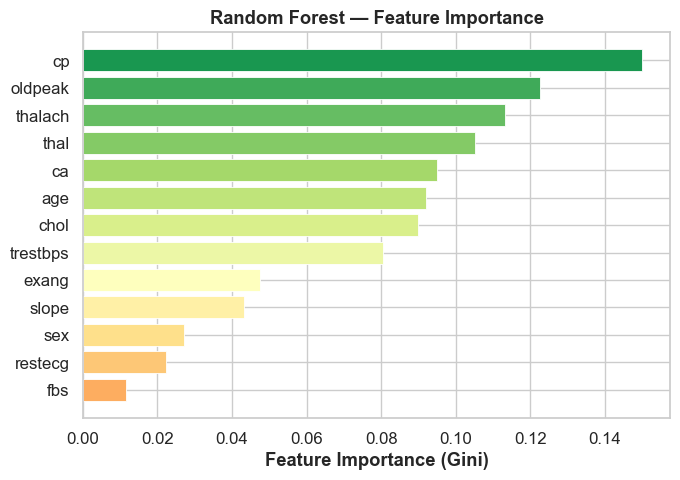

Top 5 features (Random Forest):
Feature  Importance
     cp    0.150030
oldpeak    0.122629
thalach    0.113248
   thal    0.105080
     ca    0.094863


In [25]:
# ── Random Forest Feature Importance ──────────────────────────────────────
importances = rf_model.feature_importances_
fi_df = pd.DataFrame({'Feature': ALL_FEATURES, 'Importance': importances})\
          .sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(7, 5))
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(fi_df)))
ax.barh(fi_df['Feature'], fi_df['Importance'], color=colors,
        edgecolor='white', linewidth=0.6)
ax.set_xlabel('Feature Importance (Gini)', fontweight='bold')
ax.set_title('Random Forest — Feature Importance', fontweight='bold')
plt.tight_layout()
plt.show()

print('Top 5 features (Random Forest):')
print(fi_df.sort_values('Importance', ascending=False).head().to_string(index=False))

**Verified top 5 Random Forest feature importances:**
1. `cp` (chest pain type): 0.1500
2. `oldpeak` (ST depression): 0.1226
3. `thalach` (max heart rate): 0.1132
4. `thal` (thalassemia): 0.1051
5. `ca` (vessels coloured): 0.0949

These features align well with clinical knowledge about heart disease predictors.

---
<a id='11'></a>
## 11. Model Comparison

Summary of both models evaluated on the same 60-sample held-out test set.

In [26]:
# Summary comparison table
comparison_df = pd.DataFrame({
    'Model'    : ['Logistic Regression', 'Random Forest'],
    'Accuracy' : [lr_metrics['Accuracy'],  rf_metrics['Accuracy']],
    'Precision': [lr_metrics['Precision'], rf_metrics['Precision']],
    'Recall'   : [lr_metrics['Recall'],    rf_metrics['Recall']],
    'F1 Score' : [lr_metrics['F1 Score'],  rf_metrics['F1 Score']],
    'ROC-AUC'  : [lr_metrics['ROC-AUC'],   rf_metrics['ROC-AUC']],
})
comparison_df = comparison_df.set_index('Model').round(4)
print('Model Performance Comparison (Test Set — 60 samples):')
comparison_df

Model Performance Comparison (Test Set — 60 samples):


,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Model,,,,,
Logistic Regression,0.8333,0.8462,0.7857,0.8148,0.9487
Random Forest,0.8667,0.8846,0.8214,0.8519,0.9386


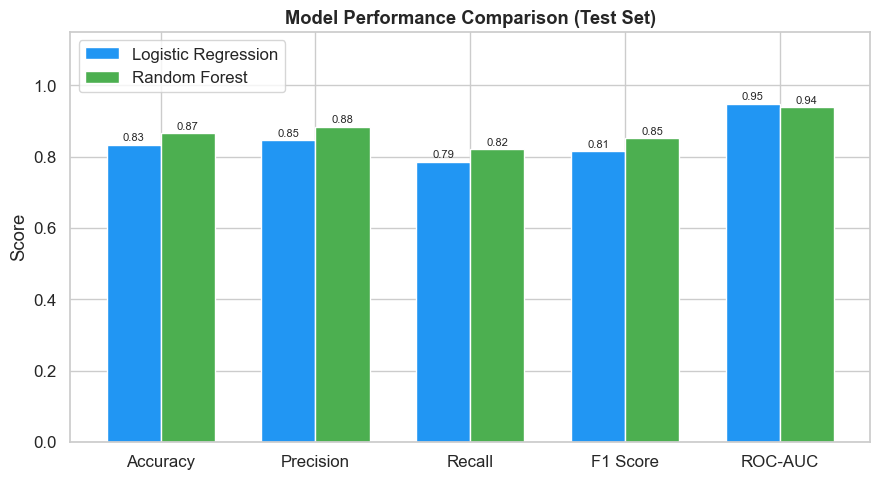

In [27]:
# Comparison bar chart
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
lr_vals = [lr_metrics[m] for m in metric_names]
rf_vals = [rf_metrics[m] for m in metric_names]

x = np.arange(len(metric_names))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars_lr = ax.bar(x - width/2, lr_vals, width, label='Logistic Regression',
                 color='#2196F3', edgecolor='white')
bars_rf = ax.bar(x + width/2, rf_vals, width, label='Random Forest',
                 color='#4CAF50', edgecolor='white')

for bars in [bars_lr, bars_rf]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(metric_names)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison (Test Set)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

**Verified results summary:**

| Model | Accuracy | Precision | Recall | F1 Score | ROC-AUC |
|-------|----------|-----------|--------|----------|---------|
| Logistic Regression | 83.33% | 84.62% | 78.57% | 81.48% | **94.87%** |
| **Random Forest** | **86.67%** | **88.46%** | **82.14%** | **85.19%** | 93.86% |

**Key finding:** Random Forest outperforms Logistic Regression on Accuracy, Precision, Recall, and F1 Score. However, Logistic Regression achieves a slightly higher ROC-AUC (94.87% vs 93.86%), meaning it has better probability calibration across decision thresholds. For a screening context where minimising missed disease cases is most important, **Recall** is the most critical metric — Random Forest achieves the higher recall (82.14% vs 78.57%).

---
<a id='12'></a>
## 12. Conclusions

This analysis successfully built and compared two machine learning classifiers for heart disease prediction using the UCI Cleveland dataset.

### Key Findings

1. **Dataset characteristics:** The cleaned dataset (297 rows) is nearly balanced, with 53.9% no-disease and 46.1% disease cases. No resampling was required.

2. **Most predictive features:** Both models consistently identified the following features as most important:
   - `cp` (chest pain type) — particularly asymptomatic type 4
   - `thalach` (max heart rate achieved) — lower values correlate with disease
   - `oldpeak` (ST depression) — higher values correlate with disease
   - `ca` (major vessels coloured) — more vessels coloured = more disease risk
   - `thal` (thalassemia type) — reversible defect type associated with disease

3. **Model performance:**
   - Both models exceed 83% accuracy on unseen test data
   - Both achieve ROC-AUC > 0.93, indicating excellent discriminative ability
   - **Random Forest is preferred** for deployment due to higher accuracy, F1, and recall
   - **Logistic Regression** provides interpretability and slightly better probability calibration

4. **Missing values:** Only 6 of 303 rows (2%) had missing values in `ca` and `thal`, which were safely dropped without impacting model quality.

5. **Data leakage prevention:** The StandardScaler was fit exclusively on training data and applied to test data, ensuring valid evaluation.

### Recommendation
For an **educational screening tool**, Random Forest is the better choice due to its higher recall (82.14%) — in a medical context, missing a true disease case (false negative) is more costly than a false alarm. For **interpretation and explainability**, Logistic Regression is preferred.

---
<a id='13'></a>
## 13. Limitations

This project has several important limitations that must be acknowledged:

1. **Small dataset size:** Only 297 usable samples is very small for a medical ML model. Results may not generalise to other populations.

2. **Single geographic source:** All data comes from the Cleveland Clinic (USA, 1980s). The dataset may not represent current populations or other demographics.

3. **No hyperparameter tuning:** Models use default or basic parameters. GridSearchCV or cross-validation would likely improve results.

4. **No cross-validation:** We used a single train/test split. K-fold cross-validation would give more reliable performance estimates.

5. **Binary classification simplification:** The original target had 5 classes (0–4 indicating severity). Converting to binary loses severity information.

6. **Feature encoding:** Categorical features were used as integers without one-hot encoding. This may imply ordinal relationships in the Logistic Regression model.

7. **No external validation:** Models have not been tested on any dataset other than the 20% holdout from this same dataset.

8. **NOT a clinical tool:** This project is solely for educational purposes and must not be used for any medical diagnosis or decision-making.

---
<a id='14'></a>
## 14. References

1. **Dataset:** Janosi, A., Steinbrunn, W., Pfisterer, M., & Detrano, R. (1988). *Heart Disease Dataset (Cleveland)*. UCI Machine Learning Repository. https://archive.ics.uci.edu/ml/datasets/Heart+Disease

2. **Scikit-learn:** Pedregosa et al. (2011). *Scikit-learn: Machine Learning in Python*. Journal of Machine Learning Research, 12, 2825–2830. https://scikit-learn.org

3. **Pandas:** McKinney, W. (2010). *Data Structures for Statistical Computing in Python*. Proceedings of the 9th Python in Science Conference. https://pandas.pydata.org

4. **Matplotlib:** Hunter, J. D. (2007). *Matplotlib: A 2D Graphics Environment*. Computing in Science & Engineering, 9(3), 90–95. https://matplotlib.org

5. **Seaborn:** Waskom, M. (2021). *seaborn: statistical data visualization*. Journal of Open Source Software, 6(60), 3021. https://seaborn.pydata.org

6. **IBM SkillsBuild:** IBM SkillsBuild Program. https://skillsbuild.org

7. **BharatCares:** BharatCares Data Analytics with AI Internship Programme.

---

> ⚠️ **Reminder:** This notebook is an educational project submitted as part of the IBM SkillsBuild & BharatCares Data Analytics with AI internship. All findings are derived from publicly available research data and are **not** intended for medical use.